# Runtime Analysis

## Sequential Clustering Algrithm

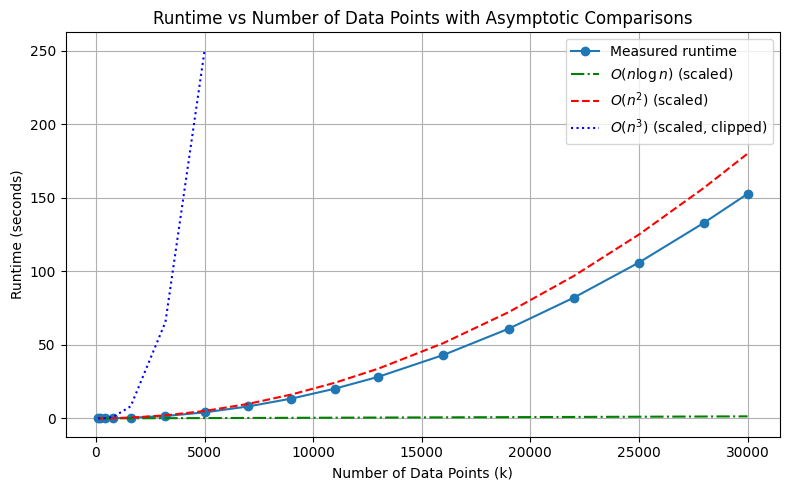

In [8]:
import numpy as np
import matplotlib.pyplot as plt

k_values = np.array([
    100, 200, 400, 800, 1600, 3200, 5000, 7000, 9000, 11000,
    13000, 16000, 19000, 22000, 25000, 28000, 30000
], dtype=np.float64)

runtime = np.array([
    0.002, 0.006, 0.024, 0.095, 0.382, 1.581, 4.057, 8.069, 13.432, 20.180,
    28.248, 43.107, 60.948, 82.061, 105.961, 133.028, 152.661
])

plt.figure(figsize=(8, 5))

# Plot measured runtime
plt.plot(k_values, runtime, 'o-', label='Measured runtime')

# Reference curves (scaled to match first runtime value)
scale_n2 = runtime[0] / (k_values[0]**2)
scale_nlogn = runtime[0] / (k_values[0]*np.log2(k_values[0]))
scale_n3 = runtime[0] / (k_values[0]**3)

n2_curve = k_values**2 * scale_n2
nlogn_curve = k_values * np.log2(k_values) * scale_nlogn
n3_curve = k_values**3 * scale_n3

# Mask only values of n^3 curve that are too large (e.g. > 300)
n3_curve_masked = np.where(n3_curve > 300, np.nan, n3_curve)

# Plot reference curves
plt.plot(k_values, nlogn_curve, 'g-.', label=r'$O(n\log n)$ (scaled)')
plt.plot(k_values, n2_curve, 'r--', label=r'$O(n^2)$ (scaled)')
plt.plot(k_values, n3_curve_masked, 'b:', label=r'$O(n^3)$ (scaled, clipped)')

# Labels and legend
plt.xlabel('Number of Data Points (k)')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime vs Number of Data Points with Asymptotic Comparisons')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
